# Rotational permutation test: factorised vs mixed selectivity

Tutorial for testing whether a Haar-random rotation across neurons gives a useful null for the
correlation between unique-variance-explained values across two features.

- **Mixed** code: each neuron cares about both `a` and `b` → corr(uv_a, uv_b) inside the rotation null.
- **Factorised** code: each neuron cares about `a` *or* `b` → corr(uv_a, uv_b) negative, outside the null.

## 1. Imports

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold

## 2. Simulate data

Spikes are generated from per-neuron weights on four latent features:

- `a, b` — the *analysed* features, each with a per-neuron weight.
- `c` — a *distractor*: drives spikes (`c_scale > 0`) but is never seen by the regression.
- `shared` — a *low-rank shared mode*: a single global signal that all neurons load on (random
  loadings), scaled by `shared_scale`. Real cortical data is dominated by shared variability of this
  kind (arousal, locomotion, drift), and it's the most likely driver of a positive rotation null.

All four latents are sampled jointly from a multivariate Gaussian with the requested pairwise correlations
(`corr_ab`, `corr_ac`, `corr_bc`, `corr_as`, `corr_bs`, `corr_cs`).

Other knobs:
- `mode='mixed'` → each neuron mixes `a` and `b`. `mode='factorised'` → each neuron loads on one of them only.
- `gen='gaussian'` → linear + Gaussian noise. `gen='poisson'` → `exp` link + Poisson sampling.
- `gain_jitter > 0` adds per-neuron multiplicative gain heterogeneity (lognormal σ).

In [ ]:
def simulate(
    n_neurons=200,
    n_samples=100,
    noise=0.5,
    mode="mixed",
    corr_ab=0.0,
    corr_ac=0.0,
    corr_bc=0.0,
    corr_as=0.0,  # corr between a and the shared latent
    corr_bs=0.0,  # corr between b and the shared latent
    corr_cs=0.0,  # corr between c and the shared latent
    c_scale=0.0,
    shared_scale=0.0,  # 0 = no shared low-rank mode; >0 = global driver across all neurons
    gen="gaussian",
    baseline=1.0,
    gain_jitter=0.0,
    rng=None,
):
    rng = rng or np.random.default_rng()

    # sample (a, b, c, shared) jointly from a multivariate Gaussian.
    Sigma = np.array(
        [
            [1.0, corr_ab, corr_ac, corr_as],
            [corr_ab, 1.0, corr_bc, corr_bs],
            [corr_ac, corr_bc, 1.0, corr_cs],
            [corr_as, corr_bs, corr_cs, 1.0],
        ]
    )
    latents = np.linalg.cholesky(Sigma) @ rng.standard_normal((4, n_samples))
    a, b, c, shared = latents

    if mode == "mixed":
        w_a = rng.standard_normal(n_neurons)
        w_b = rng.standard_normal(n_neurons)
    elif mode == "factorised":
        picks_a = rng.random(n_neurons) < 0.5
        w_a = np.where(picks_a, rng.standard_normal(n_neurons), 0.0)
        w_b = np.where(~picks_a, rng.standard_normal(n_neurons), 0.0)
    else:
        raise ValueError(f"mode must be 'mixed' or 'factorised', got {mode!r}")
    w_c = rng.standard_normal(n_neurons)  # distractor weights, scaled by c_scale below
    w_shared = rng.standard_normal(n_neurons)  # shared-mode loadings, scaled by shared_scale below

    # per-neuron gain: lognormal around 1, off when gain_jitter == 0
    gain = rng.lognormal(0, gain_jitter, n_neurons) if gain_jitter > 0 else np.ones(n_neurons)
    linpred = gain[:, None] * (
        np.outer(w_a, a)
        + np.outer(w_b, b)
        + c_scale * np.outer(w_c, c)
        + shared_scale * np.outer(w_shared, shared)
    )

    if gen == "gaussian":
        spikes = linpred + noise * rng.standard_normal(linpred.shape)
    elif gen == "poisson":
        rate = np.exp(np.clip(baseline + linpred, -10, 5))
        spikes = rng.poisson(rate).astype(float)
    else:
        raise ValueError(f"gen must be 'gaussian' or 'poisson', got {gen!r}")
    return spikes, a, b, c, w_a, w_b, w_c

## 3. Sanity check: weight scatter

Plot `w_a` vs `w_b` for both regimes — gives intuition for what "mixed" vs "factorised" means at the weight level.

In [ ]:
# --- simulation parameters (real-data-like defaults) ---
n_neurons = 200
n_samples = 200  # more samples — closer to real-session length
noise = 0.5  # gaussian-mode observation noise
corr_ab = 0.2  # weak correlation between behavioural variables
corr_ac = 0.3  # distractor correlated with a
corr_bc = 0.3  # distractor correlated with b
corr_as = 0.3  # shared mode correlated with a
corr_bs = 0.3  # shared mode correlated with b
corr_cs = 0.0  # shared mode independent of distractor
c_scale = 1.0  # distractor drives spikes
shared_scale = 1.5  # dominant shared low-rank mode (typical of cortical data)
gen = "poisson"  # real spike-count statistics
baseline = 1.0  # log baseline rate
gain_jitter = 1.0  # broad firing-rate heterogeneity (lognormal σ)
seed = 1

# --- regression parameters (used in unique_var_explained / null_metrics) ---
ridge_alpha = 0.5  # 0 = LinearRegression; >0 = Ridge with this alpha
n_folds = 5  # cross-validation folds
# -------------------------------------------------------------

sim_kwargs = dict(
    n_neurons=n_neurons,
    n_samples=n_samples,
    noise=noise,
    corr_ab=corr_ab,
    corr_ac=corr_ac,
    corr_bc=corr_bc,
    corr_as=corr_as,
    corr_bs=corr_bs,
    corr_cs=corr_cs,
    c_scale=c_scale,
    shared_scale=shared_scale,
    gen=gen,
    baseline=baseline,
    gain_jitter=gain_jitter,
)
reg_kwargs = dict(alpha=ridge_alpha, n_folds=n_folds)

spikes_mix, a_mix, b_mix, c_mix, wa_mix, wb_mix, wc_mix = simulate(
    mode="mixed", rng=np.random.default_rng(seed), **sim_kwargs
)
spikes_fac, a_fac, b_fac, c_fac, wa_fac, wb_fac, wc_fac = simulate(
    mode="factorised", rng=np.random.default_rng(seed), **sim_kwargs
)

# sanity check: empirical correlations of (a, b, c) should match what we asked for
print("empirical corr matrix of (a, b, c):")
print(np.round(np.corrcoef(np.stack([a_mix, b_mix, c_mix])), 2))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (wa, wb, title) in zip(axes, [(wa_mix, wb_mix, "mixed"), (wa_fac, wb_fac, "factorised")]):
    ax.scatter(wa, wb, s=10, alpha=0.6)
    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(0, color="k", lw=0.5)
    ax.set(xlabel="w_a", ylabel="w_b", title=title)
plt.tight_layout()
plt.show()

## 4. Cross-validated unique variance explained

For each neuron, fit a full model `[a, b]` and two reduced models `[a]`, `[b]` under K-fold CV.

- `uv_a = R²(full) − R²(b only)`
- `uv_b = R²(full) − R²(a only)`

All neurons are fitted in one sklearn call by treating them as multi-output.

In [106]:
def _r2_per_neuron(X_tr, X_te, Y_tr, Y_te, alpha=0.0):
    # alpha=0 → OLS; alpha>0 → Ridge for numerical stability under collinearity.
    model = LinearRegression() if alpha == 0 else Ridge(alpha=alpha)
    pred = model.fit(X_tr, Y_tr.T).predict(X_te).T
    ss_res = ((Y_te - pred) ** 2).sum(axis=1)
    ss_tot = ((Y_te - Y_te.mean(axis=1, keepdims=True)) ** 2).sum(axis=1)
    return 1 - ss_res / ss_tot


def unique_var_explained(spikes, a, b, alpha=0.0, n_folds=5):
    X_full = np.column_stack([a, b])
    X_a = a[:, None]
    X_b = b[:, None]
    uv_a = np.zeros(spikes.shape[0])
    uv_b = np.zeros(spikes.shape[0])
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=0)
    for tr, te in kf.split(a):
        r2_full = _r2_per_neuron(X_full[tr], X_full[te], spikes[:, tr], spikes[:, te], alpha=alpha)
        r2_a = _r2_per_neuron(X_a[tr], X_a[te], spikes[:, tr], spikes[:, te], alpha=alpha)
        r2_b = _r2_per_neuron(X_b[tr], X_b[te], spikes[:, tr], spikes[:, te], alpha=alpha)
        uv_a += (r2_full - r2_b) / n_folds
        uv_b += (r2_full - r2_a) / n_folds
    return uv_a, uv_b

## 5. Scatter of unique variance, both regimes

Compute `uv_a` and `uv_b` for the mixed and factorised datasets, scatter them, report Pearson r.

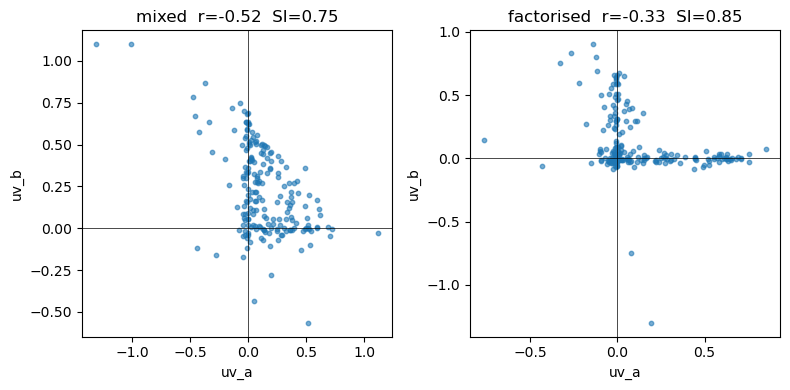

In [107]:
def mean_selectivity(uv_a, uv_b):
    # SI = 1 when a cell loads on one feature only, 0 when equal on both.
    return np.mean(np.abs(uv_a - uv_b) / (np.abs(uv_a) + np.abs(uv_b) + 1e-12))


uv_a_mix, uv_b_mix = unique_var_explained(spikes_mix, a_mix, b_mix, **reg_kwargs)
uv_a_fac, uv_b_fac = unique_var_explained(spikes_fac, a_fac, b_fac, **reg_kwargs)

corr_mix = np.corrcoef(uv_a_mix, uv_b_mix)[0, 1]
corr_fac = np.corrcoef(uv_a_fac, uv_b_fac)[0, 1]
si_mix = mean_selectivity(uv_a_mix, uv_b_mix)
si_fac = mean_selectivity(uv_a_fac, uv_b_fac)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (uva, uvb, title, r, si) in zip(
    axes,
    [(uv_a_mix, uv_b_mix, "mixed", corr_mix, si_mix), (uv_a_fac, uv_b_fac, "factorised", corr_fac, si_fac)],
):
    ax.scatter(uva, uvb, s=10, alpha=0.6)
    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(0, color="k", lw=0.5)
    ax.set(xlabel="uv_a", ylabel="uv_b", title=f"{title}  r={r:.2f}  SI={si:.2f}")
plt.tight_layout()
plt.show()

## 6. Haar-uniform rotation across neurons

Mixes the per-neuron representation linearly. A factorised population becomes mixed under the rotation,
so rotated correlations form a null for "what would corr(uv_a, uv_b) look like under a mixed code?"

In [108]:
def _rotate_spikes(spikes, rng=None):
    n_neurons = spikes.shape[0]
    if rng is None:
        Z = np.random.standard_normal((n_neurons, n_neurons))
    else:
        Z = rng.standard_normal((n_neurons, n_neurons))
    Q, R = np.linalg.qr(Z)
    Q = Q * np.sign(np.diag(R))  # Haar-uniform on O(n_neurons)
    return Q @ spikes

## 6b. One rotation, visualised

Apply `_rotate_spikes` once to each dataset, recompute unique variance, and scatter.
The factorised scatter should lose its axis-aligned structure; the mixed scatter should look essentially unchanged.

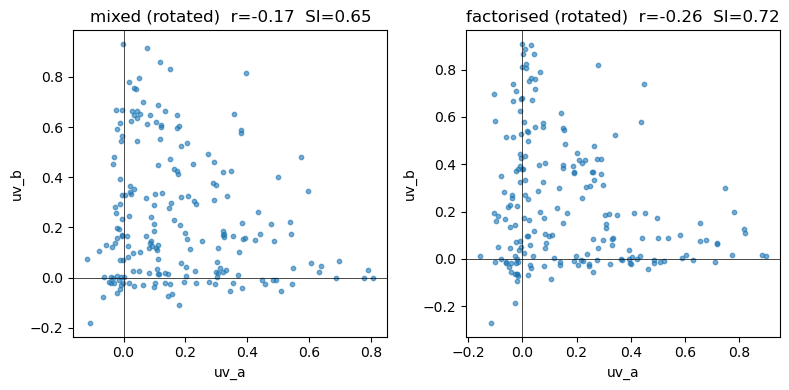

In [109]:
demo_rng = np.random.default_rng(3)
rot_mix = _rotate_spikes(spikes_mix, rng=demo_rng)
rot_fac = _rotate_spikes(spikes_fac, rng=demo_rng)

uv_a_rot_mix, uv_b_rot_mix = unique_var_explained(rot_mix, a_mix, b_mix, **reg_kwargs)
uv_a_rot_fac, uv_b_rot_fac = unique_var_explained(rot_fac, a_fac, b_fac, **reg_kwargs)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (uva, uvb, title) in zip(
    axes,
    [(uv_a_rot_mix, uv_b_rot_mix, "mixed (rotated)"), (uv_a_rot_fac, uv_b_rot_fac, "factorised (rotated)")],
):
    r = np.corrcoef(uva, uvb)[0, 1]
    si = mean_selectivity(uva, uvb)
    ax.scatter(uva, uvb, s=10, alpha=0.6)
    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(0, color="k", lw=0.5)
    ax.set(xlabel="uv_a", ylabel="uv_b", title=f"{title}  r={r:.2f}  SI={si:.2f}")
plt.tight_layout()
plt.show()

## 7. Null distribution from rotated spikes

For each rotation, compute both the across-cell correlation and the mean selectivity index.

In [110]:
def null_metrics(spikes, a, b, n_perm=500, rng=None, alpha=0.0, n_folds=5):
    rng = rng or np.random.default_rng()
    null_corr = np.empty(n_perm)
    null_si = np.empty(n_perm)
    for i in range(n_perm):
        rotated = _rotate_spikes(spikes, rng=rng)
        uv_a, uv_b = unique_var_explained(rotated, a, b, alpha=alpha, n_folds=n_folds)
        null_corr[i] = np.corrcoef(uv_a, uv_b)[0, 1]
        null_si[i] = mean_selectivity(uv_a, uv_b)
    return null_corr, null_si

## 8. True correlation vs rotation null

For each regime: histogram the null, draw a line at the true correlation, report a two-sided p-value.

Expected outcome: mixed → true line sits inside the null; factorised → true line sits to the left of the null.

> **Note on `gain_jitter`:** when `gain_jitter > 0`, mixed neurons inherit a per-cell gain that scales
> *both* `uv_a` and `uv_b`, inducing a **positive** across-neuron correlation between them. The
> rotation null is centred near 0, so the mixed `r` may now sit in the right tail. This is the
> rotation null doing its job — it tests against population structure that random mixing cannot
> reproduce, gain heterogeneity included.

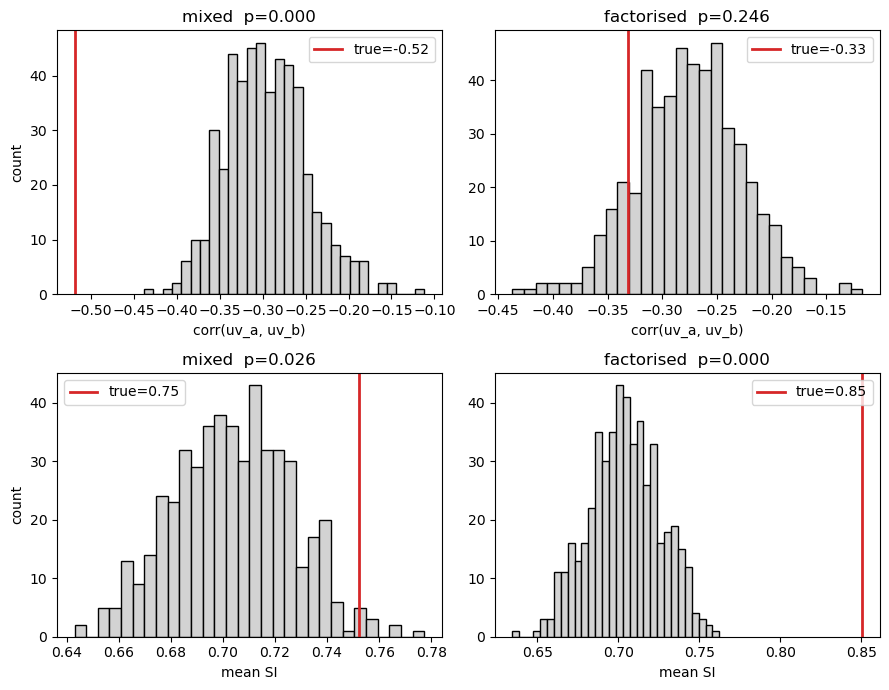

In [111]:
n_perm = 500
null_corr_mix, null_si_mix = null_metrics(
    spikes_mix, a_mix, b_mix, n_perm=n_perm, rng=np.random.default_rng(2), **reg_kwargs
)
null_corr_fac, null_si_fac = null_metrics(
    spikes_fac, a_fac, b_fac, n_perm=n_perm, rng=np.random.default_rng(2), **reg_kwargs
)


def two_sided_p(true, null):
    centre = null.mean()
    return (np.abs(null - centre) >= np.abs(true - centre)).mean()


fig, axes = plt.subplots(2, 2, figsize=(9, 7))
panels = [
    (axes[0, 0], null_corr_mix, corr_mix, "mixed", "corr(uv_a, uv_b)"),
    (axes[0, 1], null_corr_fac, corr_fac, "factorised", "corr(uv_a, uv_b)"),
    (axes[1, 0], null_si_mix, si_mix, "mixed", "mean SI"),
    (axes[1, 1], null_si_fac, si_fac, "factorised", "mean SI"),
]
for ax, null, true, title, xlabel in panels:
    p = two_sided_p(true, null)
    ax.hist(null, bins=30, color="lightgray", edgecolor="k")
    ax.axvline(true, color="C3", lw=2, label=f"true={true:.2f}")
    ax.set(xlabel=xlabel, title=f"{title}  p={p:.3f}")
    ax.legend()
axes[0, 0].set_ylabel("count")
axes[1, 0].set_ylabel("count")
plt.tight_layout()
plt.show()